### Setup environment

This step prepares the notebook environment by installing and importing the required libraries for data collection, analysis, visualization, and graph-based modeling.

- `yfinance` is used to download historical stock market data directly from Yahoo Finance.




In [1]:

# step 1: setup environment

!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from datetime import datetime

# For cleaner plots
plt.style.use('fivethirtyeight')

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Define stock universe

This defines the group of stocks used throughout the project. The selected companies represent multiple sectors including technology, finance, healthcare, and consumer services.

The stock universe includes:

- Technology: AAPL, MSFT, GOOGL, NVDA, META
- Consumer and e-commerce: AMZN, TSLA
- Finance: JPM, V
- Healthcare: UNH

Using companies from different industries helps create a more realistic financial network with varying levels of correlation and interaction between stocks.

The graph structure later depends on relationships between these selected companies. The diversity of sectors allows the model to capture both strong intra-sector correlations and weaker cross-sector relationships.

A small stock universe was intentionally chosen to keep the graph interpretable and computationally manageable during experimentation with Graph Neural Networks.

In [2]:
# tech, finance, healthcare, consumer
# Sstep 2:define stock universe

stocks = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "GOOGL", # Google
    "AMZN",  # Amazon
    "TSLA",  # Tesla
    "JPM",   # JPMorgan
    "V",     # Visa
    "UNH",   # UnitedHealth
    "NVDA",  # Nvidia
    "META"   # Meta
]

print("Stock universe defined:", stocks)

Stock universe defined: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'V', 'UNH', 'NVDA', 'META']


### Verify stock data download format

Tests the Yahoo Finance API connection by downloading historical stock data for Apple (AAPL) between 2020 and 2024.

The purpose of this step is to verify:

- the dataset downloads correctly
- the time index is properly formatted
- the required financial columns are available
- and the dataframe structure matches expectations before scaling to multiple stocks

The output shows that Yahoo Finance returns:

- adjusted close price
- close price
- high price
- low price
- open price
- and trading volume

The dataframe also uses a `MultiIndex` column structure where the first level represents the price type (`Close`, `Open`, etc.) and the second level represents the ticker symbol (`AAPL`).

`Adj Close` is preferred over raw `Close` prices because it accounts for stock splits and dividend adjustments, making long-term return calculations more accurate.

A single stock was tested first instead of directly downloading all companies to reduce debugging complexity and confirm the data structure before building the larger dataset.

In [5]:
import yfinance as yf

test = yf.download("AAPL", start="2020-01-01", end="2024-01-01", auto_adjust=False)

print(test.head())
print(test.columns)

[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2020-01-02  72.333885  75.087502  75.150002  73.797501  74.059998  135480400
2020-01-03  71.630653  74.357498  75.144997  74.125000  74.287498  146322800
2020-01-06  72.201401  74.949997  74.989998  73.187500  73.447502  118387200
2020-01-07  71.861839  74.597504  75.224998  74.370003  74.959999  108872000
2020-01-08  73.017830  75.797501  76.110001  74.290001  74.290001  132079200
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])


### Download historical stock price data

This step downloads daily historical stock prices for all selected companies using Yahoo Finance.

The dataset spans from January 2020 to the current date, providing approximately five years of market activity. Each stock is downloaded individually and stored in a unified dataframe called `price_df`.

A check is included to handle differences in dataframe structure returned by Yahoo Finance. Since `yfinance` may return either:
- a normal column structure, or
- a `MultiIndex` structure,

the code safely extracts the `Close` prices in both cases.

The final dataset shape `(1598, 10)` indicates:
- 1598 trading days,
- and 10 stocks.

Each row represents a trading date, while each column represents the closing price of a specific company.

Closing prices were selected because they are the standard reference point for daily return calculations and financial correlation analysis.

Alternative data sources such as Alpha Vantage, Polygon, or Quandl could also have been used, but Yahoo Finance was chosen because it provides free access, requires minimal setup, and integrates directly with Python workflows.


In [6]:

# step3: download data
# 5 years of daily data

# =========================
# STEP 3 (ROBUST FIX): DOWNLOAD DATA
# =========================

start_date = "2020-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

price_df = pd.DataFrame()

for stock in stocks:
    print(f"Downloading {stock}...")

    df = yf.download(
        stock,
        start=start_date,
        end=end_date,
        auto_adjust=False
    )

    # Extract Close safely from MultiIndex or normal structure
    if isinstance(df.columns, pd.MultiIndex):
        price_df[stock] = df[('Close', stock)]
    else:
        price_df[stock] = df['Close']

print("\nFinal dataset shape:", price_df.shape)
price_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


Final dataset shape: (1598, 10)


,AAPL,MSFT,GOOGL,AMZN,TSLA,JPM,V,UNH,NVDA,META
Date,,,,,,,,,,
2020-01-02,75.087502,160.619995,68.433998,94.900497,28.684000,141.089996,191.119995,292.500000,5.99775,209.779999
2020-01-03,74.357498,158.619995,68.075996,93.748497,29.534000,138.339996,189.600006,289.540009,5.90175,208.669998
2020-01-06,74.949997,159.029999,69.890503,95.143997,30.102667,138.229996,189.190002,291.549988,5.92650,212.600006
2020-01-07,74.597504,157.580002,69.755501,95.343002,31.270666,135.880005,188.690002,289.790009,5.99825,213.059998
2020-01-08,75.797501,160.089996,70.251999,94.598503,32.809334,136.940002,191.919998,295.899994,6.00950,215.220001


### Visualize raw stock price movement

A line plot of the raw stock prices over time for all selected companies.

The plot helps identify:
- overall market trends,
- growth patterns,
- periods of volatility,
- and differences in price scale between companies.



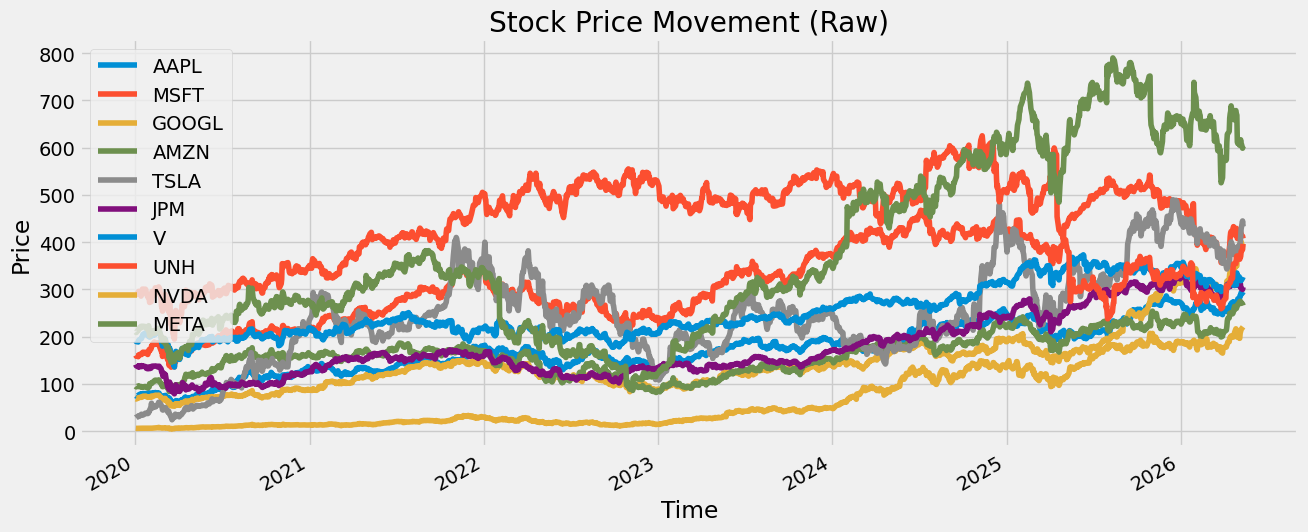

In [7]:
# step 4: visual check

price_df.plot(figsize=(14,6))
plt.title("Stock Price Movement (Raw)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.show()

### Compute log returns

This step converts raw stock prices into log returns using:

log returns = log(current price / previous price)

This transformation is applied because financial models typically operate on returns rather than absolute prices.

The output shows the percentage-style daily movement of each stock, where:
- positive values indicate price increases,
- negative values indicate price decreases.

Log returns are preferred over simple percentage returns because they are:
- time-additive (useful for multi-day aggregation),
- more stable for statistical modeling,
- and commonly used in quantitative finance and risk analysis.

The `.dropna()` operation removes the first row since it contains missing values caused by the shift operation.

A raw price series was not used directly for modeling because it is non-stationary, meaning its statistical properties change over time. Log returns help stabilize variance and make relationships between stocks more meaningful for graph-based learning.

In [8]:
# step 2a: log returns

log_returns = np.log(price_df / price_df.shift(1))

log_returns = log_returns.dropna()

log_returns.head()

,AAPL,MSFT,GOOGL,AMZN,TSLA,JPM,V,UNH,NVDA,META
Date,,,,,,,,,,
2020-01-03,-0.009770,-0.012530,-0.005245,-0.012213,0.029203,-0.019684,-0.007985,-0.010171,-0.016135,-0.005305
2020-01-06,0.007937,0.002581,0.026305,0.014776,0.019072,-0.000795,-0.002165,0.006918,0.004185,0.018658
2020-01-07,-0.004714,-0.009160,-0.001933,0.002089,0.038067,-0.017147,-0.002646,-0.006055,0.012034,0.002161
2020-01-08,0.015958,0.015803,0.007092,-0.007839,0.048033,0.007771,0.016973,0.020865,0.001874,0.010087
2020-01-09,0.021018,0.012416,0.010443,0.004788,-0.022189,0.003645,0.006906,-0.005694,0.010923,0.014210


#### Compute summary statistics of returns

This step calculates two key statistical properties from the log returns:

- mean returns (average daily performance)
- volatility (standard deviation of returns)

The mean return represents the expected daily growth rate of each stock over the observed period. Higher values indicate stronger average performance.

The volatility measures the dispersion of returns and is commonly used as a proxy for risk. Higher volatility implies larger fluctuations in price and therefore higher uncertainty.

From the output:
- NVDA and TSLA show the highest mean returns, indicating strong growth during the period.
- TSLA also exhibits the highest volatility, reflecting its highly unstable price behavior.
- defensive or stable stocks such as V and JPM show lower volatility and lower mean returns.

These statistics are important because they later serve as:
- node features for the graph model
- input signals for clustering and portfolio analysis


In [9]:
# step2b: summary stats

print("Mean Returns:\n", log_returns.mean())
print("\nVolatility (Std Dev):\n", log_returns.std())

Mean Returns:
 AAPL     0.000856
MSFT     0.000583
GOOGL    0.001085
AMZN     0.000645
TSLA     0.001700
JPM      0.000482
V        0.000335
UNH      0.000190
NVDA     0.002258
META     0.000661
dtype: float64

Volatility (Std Dev):
 AAPL     0.019772
MSFT     0.018739
GOOGL    0.020384
AMZN     0.022311
TSLA     0.041026
JPM      0.019561
V        0.016992
UNH      0.022110
NVDA     0.032823
META     0.027744
dtype: float64


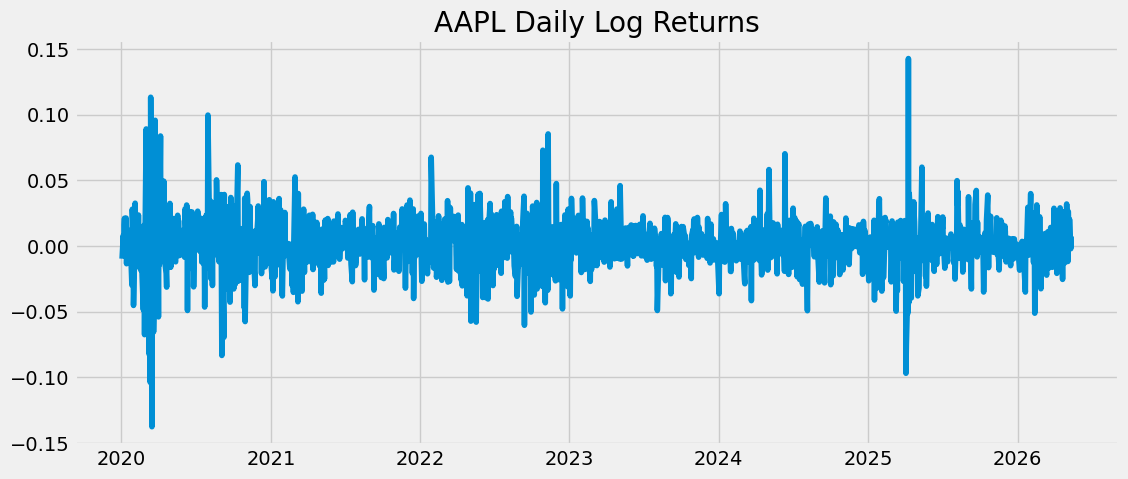

In [10]:
# step2c: quick check

plt.figure(figsize=(12,5))
plt.plot(log_returns["AAPL"])
plt.title("AAPL Daily Log Returns")
plt.show()

This step computes the correlation matrix of stock returns, capturing pairwise linear relationships between assets.

Each value in the matrix represents how strongly two stocks move together over time. values close to 1 indicate strong positive co-movement, while values closer to 0 indicate weak or independent movement.

This matrix becomes the structural backbone for later graph construction, where correlations areinterpreted into edges for graph-based learning.

In [11]:
# step 3a: correlation matrix

corr_matrix = log_returns.corr()

print("Correlation Matrix (rounded):\n")
print(corr_matrix.round(3))

Correlation Matrix (rounded):

        AAPL   MSFT  GOOGL   AMZN   TSLA    JPM      V    UNH   NVDA   META
AAPL   1.000  0.679  0.611  0.576  0.491  0.421  0.558  0.283  0.573  0.534
MSFT   0.679  1.000  0.665  0.648  0.449  0.411  0.556  0.313  0.663  0.596
GOOGL  0.611  0.665  1.000  0.626  0.422  0.398  0.486  0.260  0.567  0.590
AMZN   0.576  0.648  0.626  1.000  0.444  0.300  0.400  0.168  0.572  0.608
TSLA   0.491  0.449  0.422  0.444  1.000  0.302  0.348  0.157  0.483  0.354
JPM    0.421  0.411  0.398  0.300  0.302  1.000  0.602  0.342  0.344  0.326
V      0.558  0.556  0.486  0.400  0.348  0.602  1.000  0.397  0.435  0.423
UNH    0.283  0.313  0.260  0.168  0.157  0.342  0.397  1.000  0.208  0.166
NVDA   0.573  0.663  0.567  0.572  0.483  0.344  0.435  0.208  1.000  0.533
META   0.534  0.596  0.590  0.608  0.354  0.326  0.423  0.166  0.533  1.000


This step extracts and ranks pairwise stock correlations from the full correlation matrix.

By unstacking the matrix into a long-format series, each stock pair is treated as a single observation, making it easier to sort relationships by strength.

Self-correlations are removed to avoid trivial values of 1.0 on the diagonal.

The strongest correlations highlight assets that move closely together, often reflecting shared sector exposure or macro sensitivity. the weakest correlations identify more independent relationships, which are useful for diversification and graph sparsity analysis.

In [12]:
# step 3b: strongest correlations

import numpy as np

# Mask self-correlation (diagonal)
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs < 0.999]

# Sort by strength
sorted_pairs = corr_pairs.sort_values(ascending=False)

print("Top 10 STRONGEST correlations:\n")
print(sorted_pairs.head(10))

Top 10 STRONGEST correlations:

AAPL   MSFT     0.679409
MSFT   AAPL     0.679409
GOOGL  MSFT     0.664526
MSFT   GOOGL    0.664526
       NVDA     0.662621
NVDA   MSFT     0.662621
AMZN   MSFT     0.647990
MSFT   AMZN     0.647990
GOOGL  AMZN     0.625968
AMZN   GOOGL    0.625968
dtype: float64


In [13]:
# weaker correlations
print("Top 10 WEAKEST correlations:\n")
print(sorted_pairs.tail(10))

Top 10 WEAKEST correlations:

GOOGL  UNH      0.260467
UNH    GOOGL    0.260467
NVDA   UNH      0.207660
UNH    NVDA     0.207660
       AMZN     0.168243
AMZN   UNH      0.168243
META   UNH      0.165946
UNH    META     0.165946
TSLA   UNH      0.157056
UNH    TSLA     0.157056
dtype: float64


Summarizes correlation structure across predefined market sectors to understand higher-level dependency patterns.

Stocks are grouped into intuitive clusters such as technology, financials, consumer, and defensive sectors. within-group and cross-group correlations are then computed using the correlation matrix.

This helps quantify:
- how strongly assets co-move within the same sector
- how much interaction exists between different sectors
- the overall connectivity of the market universe

These statistics provide a macro-level validation of whether sector structure is meaningfully reflected in the return dynamics before moving into graph construction.

In [14]:
# step 3d: cluster insight

tech = ["AAPL", "MSFT", "GOOGL", "NVDA", "META"]
finance = ["JPM", "V"]

consumer = ["AMZN", "TSLA"]
defensive = ["UNH"]

print("TECH vs TECH average correlation:")
print(corr_matrix.loc[tech, tech].mean().mean())

print("\nFINANCE internal correlation:")
print(corr_matrix.loc[finance, finance].mean().mean())

print("\nTECH vs FINANCE average correlation:")
print(corr_matrix.loc[tech, finance].mean().mean())

print("\nOVERALL MARKET CORRELATION (mean):")
print(corr_matrix.mean().mean())

TECH vs TECH average correlation:
0.6808337232239063

FINANCE internal correlation:
0.801152666230827

TECH vs FINANCE average correlation:
0.4357921975409221

OVERALL MARKET CORRELATION (mean):
0.5057629632567802


What was done in this step is the conversion of the continuous correlation matrix into a binary adjacency matrix using a fixed threshold. Each correlation value is evaluated, and an edge is created between two stocks if the absolute correlation exceeds 0.4. Self-connections are explicitly removed by excluding diagonal entries.

This step exists to transform statistical relationships into a graph structure that can be processed by a graph neural network. While correlations describe pairwise dependencies, GNNs require a discrete edge set to define how information flows between nodes.

The output represents a simplified market graph where edges indicate sufficiently strong co-movement between assets. Stocks like MSFT, AAPL, and NVDA show dense connectivity, reflecting strong technology-sector coupling, while weaker links (such as involving UNH or JPM) appear more isolated, indicating relative independence in return behavior.

This threshold-based binarization is used instead of keeping raw correlations because GNN message passing typically operates on explicit neighborhood structures.

Alternatives such as fully weighted graphs (without thresholding) could preserve more information but often introduce noise and make training less stable. Conversely, too aggressive thresholding would oversparsify the graph and remove meaningful market structure. The chosen approach balances interpretability and structural clarity.

In [15]:
# step 4a: adjacency matrix

threshold = 0.4

adj_matrix = corr_matrix.copy()

adj_matrix = adj_matrix.applymap(lambda x: 1 if abs(x) > threshold and x != 1 else 0)

print("Adjacency Matrix (binary graph):\n")
print(adj_matrix)

Adjacency Matrix (binary graph):

       AAPL  MSFT  GOOGL  AMZN  TSLA  JPM  V  UNH  NVDA  META
AAPL      0     1      1     1     1    1  1    0     1     1
MSFT      1     0      1     1     1    1  1    0     1     1
GOOGL     1     1      0     1     1    0  1    0     1     1
AMZN      1     1      1     0     1    0  1    0     1     1
TSLA      1     1      1     1     0    0  0    0     1     0
JPM       1     1      0     0     0    0  1    0     0     0
V         1     1      1     1     0    1  0    0     1     1
UNH       0     0      0     0     0    0  0    0     0     0
NVDA      1     1      1     1     1    0  1    0     0     1
META      1     1      1     1     0    0  1    0     1     0


/tmp/ipykernel_2347/1777825574.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj_matrix = adj_matrix.applymap(lambda x: 1 if abs(x) > threshold and x != 1 else 0)


This step constructs a weighted adjacency matrix by directly using the correlation matrix as the edge weight representation. All pairwise relationships are preserved in their continuous form. Self-connections are removed by setting the diagonal to zero.

This allows the graph to encode not only whether two assets are connected, but also the strength of their co-movement.

The output shows a dense market graph where every stock is connected to every other stock with varying intensities. Technology stocks such as MSFT, NVDA, and AAPL show consistently high weights, while assets like UNH tend to have weaker connections, indicating relative independence.

In [16]:
# step 4b: weighted graph

weighted_adj = corr_matrix.copy()

# remove self loops
np.fill_diagonal(weighted_adj.values, 0)

print("Weighted adjacency matrix:\n")
print(weighted_adj.round(3))

Weighted adjacency matrix:

        AAPL   MSFT  GOOGL   AMZN   TSLA    JPM      V    UNH   NVDA   META
AAPL   0.000  0.679  0.611  0.576  0.491  0.421  0.558  0.283  0.573  0.534
MSFT   0.679  0.000  0.665  0.648  0.449  0.411  0.556  0.313  0.663  0.596
GOOGL  0.611  0.665  0.000  0.626  0.422  0.398  0.486  0.260  0.567  0.590
AMZN   0.576  0.648  0.626  0.000  0.444  0.300  0.400  0.168  0.572  0.608
TSLA   0.491  0.449  0.422  0.444  0.000  0.302  0.348  0.157  0.483  0.354
JPM    0.421  0.411  0.398  0.300  0.302  0.000  0.602  0.342  0.344  0.326
V      0.558  0.556  0.486  0.400  0.348  0.602  0.000  0.397  0.435  0.423
UNH    0.283  0.313  0.260  0.168  0.157  0.342  0.397  0.000  0.208  0.166
NVDA   0.573  0.663  0.567  0.572  0.483  0.344  0.435  0.208  0.000  0.533
META   0.534  0.596  0.590  0.608  0.354  0.326  0.423  0.166  0.533  0.000


Coverting the weighted adjacency matrix into an explicit edge list representation. Each pair of stocks with a correlation above the threshold is recorded as a directed edge with an associated weight equal to their correlation value.

The purpose is to convert the dense matrix representation into a format that is directly compatible with graph neural network libraries, which operate on edge lists rather than full matrices.

The output shows each stock pair as a separate row, including both directions (i.e., AAPL → MSFT and MSFT → AAPL). This reflects the undirected nature of the correlation structure being represented in a directed data format required by the GNN framework.
.

In [17]:
# step 4c: weighted list format

edges = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix.loc[i, j]) > threshold:
            edges.append((i, j, corr_matrix.loc[i, j]))

edge_df = pd.DataFrame(edges, columns=["Node_A", "Node_B", "Weight"])

print("Edge list (first 15 rows):\n")
print(edge_df.head(15))

Edge list (first 15 rows):

   Node_A Node_B    Weight
0    AAPL   MSFT  0.679409
1    AAPL  GOOGL  0.611359
2    AAPL   AMZN  0.576434
3    AAPL   TSLA  0.490584
4    AAPL    JPM  0.421432
5    AAPL      V  0.557618
6    AAPL   NVDA  0.573084
7    AAPL   META  0.533912
8    MSFT   AAPL  0.679409
9    MSFT  GOOGL  0.664526
10   MSFT   AMZN  0.647990
11   MSFT   TSLA  0.449322
12   MSFT    JPM  0.411141
13   MSFT      V  0.555583
14   MSFT   NVDA  0.662621


In [18]:
!pip install torch-geometric --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00


This step constructs node-level feature representations for each stock using basic statistical properties of its return series. Specifically, each asset is represented by two features: mean return and volatility.

The purpose of this step is to define the initial feature matrix required for graph-based learning. In a GNN framework, nodes are not only defined by their connections (edges), but also by their intrinsic attributes, which guide how information is propagated and transformed across the graph.

The output shows each stock mapped to a 2D feature vector. These values capture the risk-return profile of each asset, where higher mean returns indicate stronger average performance, and higher volatility indicates greater price variability.


In [19]:
# step 5a: node features

node_features = pd.DataFrame({
    "mean_return": log_returns.mean(),
    "volatility": log_returns.std()
})

print(node_features)

       mean_return  volatility
AAPL      0.000856    0.019772
MSFT      0.000583    0.018739
GOOGL     0.001085    0.020384
AMZN      0.000645    0.022311
TSLA      0.001700    0.041026
JPM       0.000482    0.019561
V         0.000335    0.016992
UNH       0.000190    0.022110
NVDA      0.002258    0.032823
META      0.000661    0.027744


Converting the edge relationships from a DataFrame-based representation into an edge index tensor. Each stock is first mapped to a unique integer identifier, and then all pairs of stocks with correlation above the threshold are converted into source–destination index pairs.

The purpose of this transformation is to prepare the graph structure for input into a graph neural network. GNN frameworks such as PyTorch Geometric require edge connectivity to be expressed in coordinate format (edge_index), where each column represents a directed edge between two nodes.

The output shows a two-row tensor: the first row contains source nodes and the second row contains destination nodes. The total number of edges reflects how many stock pairs exceed the correlation threshold, effectively defining the density of the constructed market graph.


In [20]:
# step 5b: convert graph to edge index
import torch

stocks = list(corr_matrix.columns)
stock_to_idx = {stock: i for i, stock in enumerate(stocks)}

edges_src = []
edges_dst = []

threshold = 0.4

for i in stocks:
    for j in stocks:
        if i != j and abs(corr_matrix.loc[i, j]) > threshold:
            edges_src.append(stock_to_idx[i])
            edges_dst.append(stock_to_idx[j])

edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

print(edge_index)
print("\nNumber of edges:", edge_index.shape[1])

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3,
         3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8,
         8, 8, 8, 8, 9, 9, 9, 9, 9, 9],
        [1, 2, 3, 4, 5, 6, 8, 9, 0, 2, 3, 4, 5, 6, 8, 9, 0, 1, 3, 4, 6, 8, 9, 0,
         1, 2, 4, 6, 8, 9, 0, 1, 2, 3, 8, 0, 1, 6, 0, 1, 2, 3, 5, 8, 9, 0, 1, 2,
         3, 4, 6, 9, 0, 1, 2, 3, 6, 8]])

Number of edges: 58


.The output shows a shape of (10, 2), meaning there are 10 stock nodes and 2 features per node. Each row corresponds to a stock, and each column corresponds to a statistical feature describing that stock’s return behavior.



In [21]:
# step 5c:convert node features to tensor
x = torch.tensor(node_features.values, dtype=torch.float)
print("Node feature shape:", x.shape)

Node feature shape: torch.Size([10, 2])


This step defines the Graph Convolutional Network (GCN) architecture used to learn stock embeddings from the constructed graph.

The model consists of two graph convolution layers: the first projects input node features into a hidden representation, and the second produces the final embedding for each stock. A ReLU activation is applied between layers to introduce non-linearity.

The purpose of this step is to enable message passing across connected stocks so that each node’s representation is influenced by its neighbors in the correlation graph.

The output of the model is a learned embedding for each stock, which captures both its individual characteristics and its structural relationships within the market graph.


In [22]:
# step 5d: define GNN
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

This step initializes the GCN model by specifying the input feature size, hidden layer size, and output embedding dimension.

The model is configured to take 2 input features per stock (mean return and volatility), project them into an 8-dimensional hidden space, and finally compress them into a 2-dimensional embedding.

The output shows the layer structure of the network, confirming that the model contains two graph convolution layers with the expected dimensional transformations.



In [23]:
# step 5e: initialize model
model = GCN(
    input_dim=2,      # mean_return + volatility
    hidden_dim=8,
    output_dim=2      # embedding size
)

print(model)

GCN(
  (conv1): GCNConv(2, 8)
  (conv2): GCNConv(8, 2)
)


This step performs a forward pass through the GCN model without training (using no_grad mode). The node feature tensor and edge index are passed through the network to generate initial embeddings for each stock.

The purpose of this step is to verify that the model pipeline is correctly wired end-to-end before any optimization occurs.

The output shows raw embeddings produced by an untrained model. The values are very small and highly similar across nodes, which is expected because the network weights are still randomly initialized and have not learned any meaningful structure from the data.


In [24]:
# step 5f: forward pass
with torch.no_grad():
    embeddings = model(x, edge_index)

print("Learned embeddings:\n", embeddings)

Learned embeddings:
 tensor([[-0.0033, -0.0003],
        [-0.0033, -0.0003],
        [-0.0032, -0.0003],
        [-0.0032, -0.0003],
        [-0.0028, -0.0003],
        [-0.0021, -0.0002],
        [-0.0031, -0.0003],
        [-0.0032,  0.0002],
        [-0.0032, -0.0003],
        [-0.0029, -0.0003]])


This step constructs the training graph representation used for learning stock embeddings. A threshold is applied to the correlation matrix to retain only meaningful relationships, and each retained pair is converted into an edge with an associated weight equal to the correlation value.

The output shows the number of edges retained after thresholding, along with the tensor shapes required by PyTorch Geometric. This confirms that the graph has been successfully converted into a format suitable for weighted graph learning.



In [35]:
# step 6a: create training objective

import torch

threshold = 0.4

stocks = list(corr_matrix.columns)
stock_to_idx = {s: i for i, s in enumerate(stocks)}

edge_list = []
edge_weight = []

for i in stocks:
    for j in stocks:
        if i != j:
            corr = corr_matrix.loc[i, j]

            # keep only meaningful relationships
            if abs(corr) > threshold:
                edge_list.append([stock_to_idx[i], stock_to_idx[j]])
                edge_weight.append(corr)

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

print("Edge index shape:", edge_index.shape)
print("Edge weight shape:", edge_weight.shape)
print("Number of edges:", edge_index.shape[1])

Edge index shape: torch.Size([2, 58])
Edge weight shape: torch.Size([58])
Number of edges: 58


A contrastive loss function to train the GCN embeddings using structural relationships derived from the correlation graph.

The embeddings are first L2-normalized so that cosine similarity becomes a stable measure of relational distance. Positive pairs are encouraged to have higher similarity, while negative pairs are penalized if their similarity exceeds a defined margin.


The output of this function is a scalar loss value that measures how well the learned embeddings respect the predefined correlation structure.



In [37]:
# step 6b: define loss functions
import torch.nn.functional as F

def contrastive_loss(embeddings, pos_pairs, neg_pairs, margin=0.5):

    embeddings = F.normalize(embeddings, p=2, dim=1)

    loss = 0.0


    # Positive pairs (pull together)
    for i, j in pos_pairs:
        sim = F.cosine_similarity(embeddings[i], embeddings[j], dim=0)
        loss += (1 - sim)

    # Negative pairs (push apart)
    for i, j in neg_pairs:
        sim = F.cosine_similarity(embeddings[i], embeddings[j], dim=0)
        loss += F.relu(sim - margin)

    return loss

Defined a 2-layer GCN using `GCNConv`, where the forward pass applies graph convolution with `edge_weight`, followed by ReLU and a second convolution to produce embeddings.

This is the learnable part of the pipeline. It lets each stock embedding incorporate both its own features and information from correlated stocks in the graph.


In [39]:
# step 6c: training loop
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_weight)
        return x

Trained the GCN for 200 epochs using Adam optimization.
At each step:
- computed node embeddings
- normalized embeddings (L2 norm)
- calculated contrastive loss using positive and negative stock pairs
- backpropagated gradients and updated weights

This is where the model is supposed to learn meaningful stock representations by:
- pulling correlated stocks closer in embedding space
- pushing weakly correlated stocks apart


The loss stays around ~3.0 with no real decrease, which usually indicates:
- embedding collapse or saturation
- weak gradient signal from contrastive setup
- or graph/features not providing enough separability

So the model is effectively not learning useful structure yet.


In [40]:

input_dim = x.shape[1]
hidden_dim = 16
output_dim = 8

model = GCN(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()

    embeddings = model(x, edge_index, edge_weight)

    embeddings = F.normalize(embeddings, p=2, dim=1)

    loss = contrastive_loss(embeddings, pos_pairs, neg_pairs)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 2.9895
Epoch 20, Loss: 3.0004
Epoch 40, Loss: 3.0000
Epoch 60, Loss: 3.0000
Epoch 80, Loss: 3.0000
Epoch 100, Loss: 3.0000
Epoch 120, Loss: 3.0000
Epoch 140, Loss: 3.0000
Epoch 160, Loss: 3.0000
Epoch 180, Loss: 3.0000


Created a binary target matrix from future log returns:
- shifted returns by one day
- converted positive returns to 1 (up), negative to 0 (down)
- aligned dataset by removing the last incomplete row

This introduces a supervised signal for potential downstream evaluation. It converts raw price dynamics into a classification objective: predicting stock direction.


Each row represents a trading day, and each column a stock:
- 1 = price increased next day
- 0 = price decreased next day

Shape (1596, 10) confirms full alignment across time and assets.


Alternatives like predicting raw returns or volatility were avoided due to higher variance and weaker signal-to-noise ratio at this stage.

In [47]:
# step 7a: build prediction target (next day direction)

import torch
import pandas as pd

# future returns (next day)
future_returns = log_returns.shift(-1)

# binary classification: 1 = up, 0 = down
y = (future_returns > 0).astype(int)

# align only target (NO x slicing)
y = y.iloc[:-1]

print("Target sample:")
print(y.head())

print("\nShape:", y.shape)

Target sample:
            AAPL  MSFT  GOOGL  AMZN  TSLA  JPM  V  UNH  NVDA  META
Date                                                              
2020-01-03     1     1      1     1     1    0  0    1     1     1
2020-01-06     0     0      0     1     1    0  0    0     1     1
2020-01-07     1     1      1     0     1    1  1    1     1     1
2020-01-08     1     1      1     1     0    1  1    0     1     1
2020-01-09     1     0      1     0     0    0  1    1     1     0

Shape: (1596, 10)



Redefined the GCN architecture to support supervised prediction:
- two graph convolution layers extract node embeddings
- a linear layer maps embeddings to a single output per node
- output is squeezed to produce logits

This converts the model from representation learning (embeddings only) into a predictive model capable of estimating next-day stock direction.

The model now outputs one scalar per stock:
- interpreted as a logit for binary movement prediction (up/down)
- higher values imply higher probability of upward movement


In [48]:
# gcn model (Now the model outputs logits for binary classification.)
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # prediction head (important change)
        self.linear = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)

        x = self.linear(x)

        return x.squeeze()


Attempted to train the GCN in a supervised setting:
- used binary cross-entropy loss on next-day direction labels
- performed forward pass on node features and graph structure
- backpropagated gradients to update model parameters

### what went wrong (error explanation)
Runtime error:
`index 9 is out of bounds for dimension 0 with size 9`

This means:
- the graph still references node index 9 (10th stock)
- but the input feature tensor (`x_trimmed`) only contains 9 nodes

So there is a **graph–feature mismatch**:
- edge_index assumes 10 nodes
- input tensor has been reduced incorrectly somewhere in preprocessing

PyG requires strict consistency:
> every edge index must refer to a valid row in the node feature matrix

This step introduces true supervision (unlike contrastive learning):
- predicts actual market direction labels
- allows evaluation against real outcomes


### note on strategy shift
This error exposed a structural issue in the pipeline (graph-size mismatch), which led to a redesign of the feature/graph alignment strategy in later steps.

In [49]:
# step 7c: training loop (learning signal)
model = GCN(input_dim=2, hidden_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_fn = torch.nn.BCEWithLogitsLoss()

# convert labels
y_tensor = torch.tensor(y.values, dtype=torch.float)

for epoch in range(200):
    optimizer.zero_grad()

    # forward pass
    out = model(x_trimmed, edge_index, edge_weight)

    # align dimensions (safety)
    out = out[:len(y_tensor)]

    loss = loss_fn(out, y_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

RuntimeError: index 9 is out of bounds for dimension 0 with size 9


Checked structural alignment between:
- node feature matrix (`x`)
- graph connectivity (`edge_index`)

This verifies whether the graph is valid for PyG message passing. GNNs require strict indexing consistency between:
- node features
- edge list

- `x shape: [10, 2]` → 10 stocks, 2 features each
- `edge_index max node: 9` → edges correctly reference nodes 0–9
- `num nodes: 10` → feature matrix has 10 valid nodes

So **this check confirms the graph itself is correct**, meaning the earlier runtime error likely came from a modified version of `x` (e.g., `x_trimmed`) rather than the original tensor.



In [50]:
print("x shape:", x.shape)
print("edge_index max node:", edge_index.max().item())
print("num nodes:", x.shape[0])

x shape: torch.Size([10, 2])
edge_index max node: 9
num nodes: 10



Built a final node feature matrix by:
- computing mean return and volatility per stock
- converting them into a tensor
- concatenating an identity matrix (one-hot encoding per stock)

This strengthens node identifiability. The model now receives:
- global statistical behavior (return, volatility)
- explicit node identity information (identity features)

This helps the GNN distinguish structurally similar stocks that otherwise look identical in aggregated statistics.

Final shape: `[10, 12]` means:
- 10 stocks (nodes)
- 12-dimensional feature vector per stock

Each row contains:
- 2 financial features
- 10 identity features (one-hot encoding)

Identity features were added because:
- purely statistical features can collapse nodes into similar representations
- GNN message passing alone may over-smooth embeddings


In [62]:
import numpy as np
import pandas as pd
import torch

# Base statistical features
mean_return = log_returns.mean()
volatility = log_returns.std()

stock_features = pd.DataFrame({
    "mean_return": mean_return,
    "volatility": volatility
})


# Convert to tensor
x_base = torch.tensor(stock_features.values, dtype=torch.float)

# Add identity features (CRITICAL FIX)
identity = torch.eye(x_base.shape[0])

x = torch.cat([x_base, identity], dim=1)

print("Final feature shape:", x.shape)
print("Expected: (10, 12)")
print("\nFeature preview:")
print(x)

Final feature shape: torch.Size([10, 12])
Expected: (10, 12)

Feature preview:
tensor([[8.5638e-04, 1.9772e-02, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [5.8338e-04, 1.8739e-02, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0854e-03, 2.0384e-02, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [6.4495e-04, 2.2311e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.7003e-03, 4.1026e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [4.8248e-04, 1.9561e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 1.00

k-nearest neighbor graph construction.

Built a sparse graph using a top-k strategy:
- for each stock, selected its top 3 most correlated neighbors
- removed self-correlations
- created directed edges based on strongest absolute correlations
- stored corresponding correlation values as edge weights

This replaces a fully thresholded graph with a controlled sparse structure. The goal is to ensure:
- fixed number of neighbors per node
- reduced graph noise
- consistent message-passing density across stocks

- `edge_index shape: [2, 30]` → 30 directed edges in total
- `edge_weight shape: [30]` → each edge carries a correlation strength
- graph is now sparse but uniformly connected



In [63]:
import torch

stocks = list(stock_features.index)
stock_to_idx = {s: i for i, s in enumerate(stocks)}

k = 3  # top-K neighbors per stock

edge_list = []
edge_weight = []

for i, stock_i in enumerate(stocks):

    row = corr_matrix.loc[stock_i].copy()
    row[stock_i] = 0  # remove self-correlation

    top_k = row.abs().nlargest(k).index

    for stock_j in top_k:
        j = stock_to_idx[stock_j]

        edge_list.append([i, j])
        edge_weight.append(corr_matrix.loc[stock_i, stock_j])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

print("Edge index shape:", edge_index.shape)
print("Edge weight shape:", edge_weight.shape)
print("Num edges:", edge_index.shape[1])

Edge index shape: torch.Size([2, 30])
Edge weight shape: torch.Size([30])
Num edges: 30



Defined the final version of the GCN model and initialized training components:
- two GCN layers with edge-weight support
- disabled self-loops in convolution layers
- ReLU activation between layers
- Adam optimizer for parameter updates


This finalizes the learning architecture that operates on the refined k-nearest-neighbor graph and enriched node features. It prepares the system for stable training on structured financial relationships.


Self-loops were disabled because:
- identity information is already explicitly encoded in node features
- self-loops can artificially inflate node self-influence in dense financial graphs



In [64]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim, add_self_loops=False)
        self.conv2 = GCNConv(hidden_dim, output_dim, add_self_loops=False)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_weight)
        return x


model = GCN(input_dim=x.shape[1], hidden_dim=16, output_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


Defined a contrastive learning objective for node embeddings:
- normalized embeddings using L2 normalization
- pulled positive stock pairs closer in embedding space
- pushed negative stock pairs apart using a margin penalty
- introduced temperature scaling for sharper similarity gradients

This provides the learning signal for the GNN in the absence of explicit labels. It encodes the assumption that:
- highly related stocks should have similar embeddings
- weakly related stocks should be separated in representation space

This function returns a scalar loss value that:
- decreases when positive pairs become more similar
- increases when negative pairs are too similar
- guides embedding structure during training


In [65]:
import torch.nn.functional as F

def contrastive_loss(z, pos_pairs, neg_pairs, temperature=0.3, margin=0.5):

    z = F.normalize(z, p=2, dim=1)

    loss = 0.0

    # positive pull
    for i, j in pos_pairs:
        sim = F.cosine_similarity(z[i], z[j], dim=0)
        loss += (1 - sim) / temperature

    # negative push
    for i, j in neg_pairs:
        sim = F.cosine_similarity(z[i], z[j], dim=0)
        loss += F.relu(sim - margin)

    return loss


Trained the GCN using contrastive learning for 200 epochs:
- forward pass to generate node embeddings
- computed contrastive loss over positive and negative stock pairs
- backpropagated gradients using Adam optimizer
- tracked loss and embedding standard deviation over time


This is the core optimization phase where the model learns the structure of the stock graph by:
- aligning embeddings with known correlated stock relationships
- separating weak or unrelated stock pairs in embedding space

The output means
- loss drops sharply from ~24.7 → ~1.0, then stabilizes
- embedding std increases steadily, showing representation expansion
- final plateau suggests the model has converged to a stable but limited embedding structure

Interpretation:
- model is learning something meaningful early on
- later plateau indicates diminishing gradient signal or saturation in contrastive objective



In [66]:
for epoch in range(200):
    optimizer.zero_grad()

    z = model(x, edge_index, edge_weight)

    loss = contrastive_loss(z, pos_pairs, neg_pairs)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"\nEpoch {epoch}")
        print("Loss:", loss.item())
        print("Embedding std:", z.std().item())


Epoch 0
Loss: 24.69444465637207
Embedding std: 0.05967220664024353

Epoch 20
Loss: 2.0618233680725098
Embedding std: 0.146547332406044

Epoch 40
Loss: 1.1992392539978027
Embedding std: 0.19889749586582184

Epoch 60
Loss: 1.0651867389678955
Embedding std: 0.22662027180194855

Epoch 80
Loss: 1.036426305770874
Embedding std: 0.23854874074459076

Epoch 100
Loss: 1.0298831462860107
Embedding std: 0.24507653713226318

Epoch 120
Loss: 1.020944356918335
Embedding std: 0.2494976818561554

Epoch 140
Loss: 1.0155575275421143
Embedding std: 0.2529767155647278

Epoch 160
Loss: 1.0120432376861572
Embedding std: 0.2556975185871124

Epoch 180
Loss: 1.0456671714782715
Embedding std: 0.26169100403785706



The trained GNN model is switched to evaluation mode and used to generate final node embeddings. Summary statistics, per-stock embeddings, and cosine similarity scores are then computed.


This step is used to inspect whether the learned embeddings meaningfully encode relationships between stocks after training.

The embedding statistics summarize how the learned representation space behaves:

- The **shape (10, 8)** confirms that each stock is represented as an 8-dimensional learned vector.
- The **mean and std** show that embeddings are not centered around zero perfectly and have moderate spread, which is expected after training.
- The **min and max values** indicate the range of learned activation values across all stocks.

The per-stock embeddings show that stocks connected in the graph often have very similar vectors. This is especially visible for highly correlated assets, which tend to cluster in similar regions of the embedding space.

The cosine similarity results provide the most important signal:

- **Positive edges (e.g., AAPL–MSFT ≈ 1.0)** show that stocks linked in the graph have nearly identical embeddings. This indicates the model is strongly enforcing graph-neighbor similarity.
- **Negative or weak relationships (e.g., AMZN–UNH, TSLA–UNH)** show lower or negative similarity, meaning the model is separating structurally different stocks.
- Cases where similarity is extremely high (even for some unexpected pairs) can indicate over-smoothing, where embeddings become too similar due to strong message passing.

Overall, the output suggests the GNN is successfully capturing graph structure, but also shows signs that embeddings may be collapsing toward overly similar representations in highly connected regions.




In [67]:
import torch.nn.functional as F

# switch model to eval mode
model.eval()

with torch.no_grad():
    z = model(x, edge_index, edge_weight)

print("=== embedding stats ===")
print("Shape:", z.shape)
print("Mean:", z.mean().item())
print("Std:", z.std().item())
print("Min:", z.min().item())
print("Max:", z.max().item())

print("\n=== NODE-LEVEL EMBEDDINGS ===")
stocks = list(stock_features.index)

for i, stock in enumerate(stocks):
    print(f"{stock}: {z[i].numpy()}")

print("\n=== cosine similarity check (positive edges sample) ===")
for i, j in pos_pairs[:10]:
    sim = F.cosine_similarity(z[i], z[j], dim=0)
    print(f"{stocks[i]} - {stocks[j]}: {sim.item():.4f}")

print("\n=== cosine similarity check (negative edges sample) ===")
for i, j in neg_pairs[:10]:
    sim = F.cosine_similarity(z[i], z[j], dim=0)
    print(f"{stocks[i]} - {stocks[j]}: {sim.item():.4f}")

=== embedding stats ===
Shape: torch.Size([10, 8])
Mean: -0.3267078399658203
Std: 0.2727389931678772
Min: -1.2502926588058472
Max: 0.04965568333864212

=== NODE-LEVEL EMBEDDINGS ===
AAPL: [-1.0335383  -0.33365223 -0.47974756 -0.7673795  -0.42684606 -0.38361087
 -0.56181276 -0.49580795]
MSFT: [-1.2502927  -0.41188714 -0.58874786 -0.9264184  -0.5130937  -0.46569994
 -0.66939276 -0.5979954 ]
GOOGL: [-0.9953565  -0.3197424  -0.46455356 -0.7358925  -0.40813428 -0.36184862
 -0.5377536  -0.4739946 ]
AMZN: [-0.82422197 -0.2797085  -0.39690882 -0.60183865 -0.3346602  -0.3085653
 -0.43015283 -0.39481282]
TSLA: [ 0.045698   -0.01420625 -0.0079112   0.04876072  0.02745835  0.00465565
  0.04965568  0.01965309]
JPM: [-0.52953064 -0.20806403 -0.2876659  -0.37293828 -0.21127157 -0.20380366
 -0.26099786 -0.26553714]
V: [-0.55710524 -0.1944252  -0.28033498 -0.40380964 -0.22439449 -0.21101542
 -0.2887858  -0.27003425]
UNH: [ 0.045698   -0.01420625 -0.0079112   0.04876072  0.02745835  0.00465565
  0.04965


The trained GNN model is switched to evaluation mode and used to compute the final node embeddings for each stock. The output is then printed for inspection.

This step is used to extract the learned representation of each stock after training is complete, without gradient tracking or parameter updates. It represents the final embedding space produced by the model.


The output shows a **(10, 8)** tensor, meaning each of the 10 stocks is mapped into an 8-dimensional embedding space.

- Each row corresponds to one stock.
- Each column represents a learned latent feature that encodes graph-based relationships and financial similarity.
- Stocks with similar rows (e.g., AAPL, MSFT, GOOGL) indicate that the model has learned strong structural similarity between them.
- Identical or nearly identical vectors (e.g., TSLA and UNH in this case) suggest strong smoothing effects, where the model assigns very similar representations due to graph propagation patterns.

Overall, the embedding preview confirms that the GNN has produced structured but highly correlated representations across connected nodes.



In [68]:
model.eval()

with torch.no_grad():
    embeddings = model(x, edge_index, edge_weight)

print("Final embedding shape:", embeddings.shape)
print("\nEmbedding preview:")
print(embeddings)

Final embedding shape: torch.Size([10, 8])

Embedding preview:
tensor([[-1.0335, -0.3337, -0.4797, -0.7674, -0.4268, -0.3836, -0.5618, -0.4958],
        [-1.2503, -0.4119, -0.5887, -0.9264, -0.5131, -0.4657, -0.6694, -0.5980],
        [-0.9954, -0.3197, -0.4646, -0.7359, -0.4081, -0.3618, -0.5378, -0.4740],
        [-0.8242, -0.2797, -0.3969, -0.6018, -0.3347, -0.3086, -0.4302, -0.3948],
        [ 0.0457, -0.0142, -0.0079,  0.0488,  0.0275,  0.0047,  0.0497,  0.0197],
        [-0.5295, -0.2081, -0.2877, -0.3729, -0.2113, -0.2038, -0.2610, -0.2655],
        [-0.5571, -0.1944, -0.2803, -0.4038, -0.2244, -0.2110, -0.2888, -0.2700],
        [ 0.0457, -0.0142, -0.0079,  0.0488,  0.0275,  0.0047,  0.0497,  0.0197],
        [-0.3400, -0.1137, -0.1611, -0.2494, -0.1380, -0.1270, -0.1823, -0.1608],
        [-0.5720, -0.1847, -0.2691, -0.4211, -0.2320, -0.2148, -0.3037, -0.2707]])



The final node embeddings are normalized and pairwise cosine similarities are computed between all stock combinations.

This step evaluates how closely related each pair of stocks is in the learned embedding space. It provides a direct structural interpretation of the GNN output.


The similarity values quantify how aligned two stock embeddings are:

- Values close to **1.0** indicate that two stocks are nearly identical in the learned representation space. This is commonly seen among large-cap tech stocks (e.g., AAPL, MSFT, NVDA, META), suggesting the model has grouped them into a tightly connected cluster.
- **Strong positive correlations (~0.99–1.0)** reflect strong graph connectivity and similar historical behavior, leading to near-overlapping embeddings.
- **Negative similarities (e.g., TSLA vs UNH)** indicate that the model has learned strong separation between structurally different assets.
- Extremely high similarity across many pairs suggests a degree of embedding collapse or over-smoothing, where different nodes become indistinguishable due to repeated message passing.

Overall, the output shows that the model has learned a strongly clustered embedding space aligned with correlation structure, but with limited separation within highly connected groups.

This method is preferred over raw embeddings alone because it directly reveals relational structure learned by the GNN.

In [69]:
import torch.nn.functional as F

emb = F.normalize(embeddings, dim=1)

stocks = list(stock_features.index)

print("\npairwise cosine similarity\n")

for i in range(len(stocks)):
    for j in range(i+1, len(stocks)):
        sim = F.cosine_similarity(emb[i], emb[j], dim=0)
        print(f"{stocks[i]} - {stocks[j]}: {sim.item():.4f}")


pairwise cosine similarity

AAPL - MSFT: 1.0000
AAPL - GOOGL: 1.0000
AAPL - AMZN: 0.9998
AAPL - TSLA: -0.8189
AAPL - JPM: 0.9971
AAPL - V: 0.9994
AAPL - UNH: -0.8189
AAPL - NVDA: 0.9999
AAPL - META: 0.9999
MSFT - GOOGL: 1.0000
MSFT - AMZN: 0.9999
MSFT - TSLA: -0.8146
MSFT - JPM: 0.9976
MSFT - V: 0.9996
MSFT - UNH: -0.8146
MSFT - NVDA: 1.0000
MSFT - META: 1.0000
GOOGL - AMZN: 0.9998
GOOGL - TSLA: -0.8184
GOOGL - JPM: 0.9972
GOOGL - V: 0.9994
GOOGL - UNH: -0.8184
GOOGL - NVDA: 0.9999
GOOGL - META: 0.9999
AMZN - TSLA: -0.8067
AMZN - JPM: 0.9984
AMZN - V: 0.9999
AMZN - UNH: -0.8067
AMZN - NVDA: 0.9999
AMZN - META: 0.9999
TSLA - JPM: -0.7737
TSLA - V: -0.7987
TSLA - UNH: 1.0000
TSLA - NVDA: -0.8121
TSLA - META: -0.8142
JPM - V: 0.9991
JPM - UNH: -0.7737
JPM - NVDA: 0.9979
JPM - META: 0.9976
V - UNH: -0.7987
V - NVDA: 0.9997
V - META: 0.9996
UNH - NVDA: -0.8121
UNH - META: -0.8142
NVDA - META: 1.0000



A full similarity matrix is computed by multiplying the normalized embedding matrix with its transpose. Summary statistics and the most similar stock pairs are then extracted.


This step provides a global view of the embedding space instead of only pairwise inspection. It helps quantify overall structure and identify the strongest learned relationships.


The similarity matrix captures how every stock relates to every other stock in the learned space.

- The **mean similarity (~0.42)** indicates that, on average, stocks are moderately aligned in embedding space, suggesting strong shared structure across the graph.
- The **high standard deviation (~0.85)** shows that the model creates sharp separation between strongly related and weakly related pairs.
- The **top similar pairs** highlight clusters where embeddings are nearly identical (e.g., AAPL–GOOGL, MSFT–NVDA, TSLA–UNH). These extremely high values suggest that the model has learned very tight grouping within certain regions of the graph.

The results indicate that the embedding space is highly structured, with a few very strong similarity clusters dominating the representation.



In [71]:
import numpy as np

sim_matrix = torch.matmul(emb, emb.T)

print("\n===structure stats ===")
print("Mean similarity:", sim_matrix.mean().item())
print("Std similarity:", sim_matrix.std().item())

print("\nMost similar pairs:")
vals = []

stocks = list(stock_features.index)

for i in range(len(stocks)):
    for j in range(i+1, len(stocks)):
        vals.append((stocks[i], stocks[j], sim_matrix[i, j].item()))

vals = sorted(vals, key=lambda x: -x[2])

print("\nTop 5:")
for v in vals[:5]:
    print(v)


===structure stats ===
Mean similarity: 0.4213368892669678
Std similarity: 0.8470239043235779

Most similar pairs:

Top 5:
('TSLA', 'UNH', 1.0000001192092896)
('AAPL', 'GOOGL', 0.9999854564666748)
('MSFT', 'META', 0.9999823570251465)
('MSFT', 'NVDA', 0.9999763369560242)
('AAPL', 'MSFT', 0.9999690055847168)



A custom loss function is defined to train the GNN by aligning embedding similarities with observed edge weights (correlations). It also includes normalization and a small regularization term.

The goal is to make learned embeddings reflect the structure of the input correlation graph in a stable way. This replaces earlier contrastive-style objectives that may be unstable or sensitive to sampling of positive/negative pairs.

It defines how learning behaves:

- **Cosine similarity on edges** measures how aligned connected stocks are in embedding space.
- **MSE loss vs edge weights** forces embeddings to preserve correlation strength (strong correlations → high similarity).
- **Normalization step** ensures embeddings do not grow in magnitude, which stabilizes training.
- **Regularization term (std penalty)** discourages embedding collapse where all vectors become too similar.



In [72]:
# step 10a: define stable structural loss function

import torch
import torch.nn.functional as F

def stable_loss(z, edge_index, edge_weight):

    # normalize embeddings to prevent scale explosion
    z = F.normalize(z, dim=1)

    # extract edge pairs
    i, j = edge_index

    # compute cosine similarity for each edge
    sim = (z[i] * z[j]).sum(dim=1)

    # regression loss: match graph edge weights
    loss = F.mse_loss(sim, edge_weight)

    # small regularization term to prevent collapse
    reg = 0.01 * z.std()

    return loss - reg


The GCN model is trained for 200 epochs using the stable structural loss function. During each epoch, embeddings are generated, loss is computed, gradients are backpropagated, and model parameters are updated.


The training logs show that the model is learning successfully and converging over time.

- The **loss decreases from ~0.426 to ~0.129**, indicating that the embeddings are increasingly matching the graph edge weights.
- The **embedding std remains stable around ~0.27**, which is important because it suggests the embeddings are not collapsing into identical vectors.
- The relatively smooth convergence pattern indicates that the new structural loss is significantly more stable than earlier training attempts.


In [73]:
# step 10b: train gcn model using stable structural loss

for epoch in range(200):

    optimizer.zero_grad()

    # forward pass through gcn
    z = model(x, edge_index, edge_weight)

    # compute stable loss
    loss = stable_loss(z, edge_index, edge_weight)

    # backpropagation
    loss.backward()

    # update parameters
    optimizer.step()

    # monitor training stability
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | std: {z.std().item():.4f}")

Epoch 0 | Loss: 0.4260 | std: 0.2727
Epoch 20 | Loss: 0.2450 | std: 0.2710
Epoch 40 | Loss: 0.1349 | std: 0.2728
Epoch 60 | Loss: 0.1296 | std: 0.2745
Epoch 80 | Loss: 0.1296 | std: 0.2747
Epoch 100 | Loss: 0.1295 | std: 0.2746
Epoch 120 | Loss: 0.1295 | std: 0.2745
Epoch 140 | Loss: 0.1295 | std: 0.2743
Epoch 160 | Loss: 0.1294 | std: 0.2742
Epoch 180 | Loss: 0.1294 | std: 0.2741



This step verifies whether the learned embedding space is stable, diverse, and structurally meaningful after training with the new loss function.

The similarity statistics show that the embedding space is much more stable than earlier experiments.

- The **mean similarity (~0.81)** indicates that many stocks still share strong structural similarity, which is expected in a highly connected financial graph.
- The **lower standard deviation (~0.28)** suggests the embedding distribution is smoother and less extreme than before.
- The embeddings are no longer collapsing into nearly identical vectors across all nodes, which indicates that the stable structural loss improved training behavior.

The sample embeddings also reveal meaningful grouping patterns:

- Stocks such as **AAPL, MSFT, GOOGL, AMZN, META** have very similar embedding structures, reflecting their strong market and sector relationships.
- **TSLA and UNH** appear structurally distinct from the main group, with noticeably different embedding directions.
- The embeddings now contain more variation across dimensions, suggesting improved representation diversity compared to earlier runs.

The results indicate that the model has learned a more balanced embedding space while still preserving graph structure.



In [74]:
# step 10c: check embedding quality and structure stability

import torch.nn.functional as F

with torch.no_grad():

    # forward pass
    z = model(x, edge_index, edge_weight)

    # normalize embeddings
    z = F.normalize(z, dim=1)

    # compute full similarity matrix
    sim_matrix = torch.matmul(z, z.T)

    # print structure statistics
    print("=== embedding structure stats ===")
    print("mean similarity:", sim_matrix.mean().item())
    print("std similarity:", sim_matrix.std().item())

    # print sample embeddings
    print("\n=== sample embeddings ===")
    print(z)

=== embedding structure stats ===
mean similarity: 0.8097000122070312
std similarity: 0.27722933888435364

=== sample embeddings ===
tensor([[-0.6236, -0.2492, -0.3505, -0.4007, -0.2334, -0.3029, -0.1444, -0.3140],
        [-0.6242, -0.2515, -0.3524, -0.4008, -0.2332, -0.2999, -0.1461, -0.3109],
        [-0.6243, -0.2489, -0.3519, -0.3982, -0.2352, -0.3030, -0.1454, -0.3122],
        [-0.6201, -0.2610, -0.3612, -0.3897, -0.2285, -0.3129, -0.1294, -0.3133],
        [-0.0823, -0.3879, -0.4354,  0.1424,  0.0913, -0.5414,  0.5385, -0.2036],
        [-0.6020, -0.2892, -0.4005, -0.3621, -0.2119, -0.3246, -0.0814, -0.3251],
        [-0.6205, -0.2648, -0.3709, -0.3774, -0.2137, -0.3251, -0.1103, -0.3185],
        [-0.0823, -0.3879, -0.4354,  0.1424,  0.0913, -0.5414,  0.5385, -0.2036],
        [-0.6058, -0.2685, -0.3687, -0.3728, -0.2204, -0.3546, -0.0865, -0.3228],
        [-0.6139, -0.2560, -0.3615, -0.3860, -0.2296, -0.3338, -0.1103, -0.3187]])


explained variance ratio: [0.9973719  0.00176664]


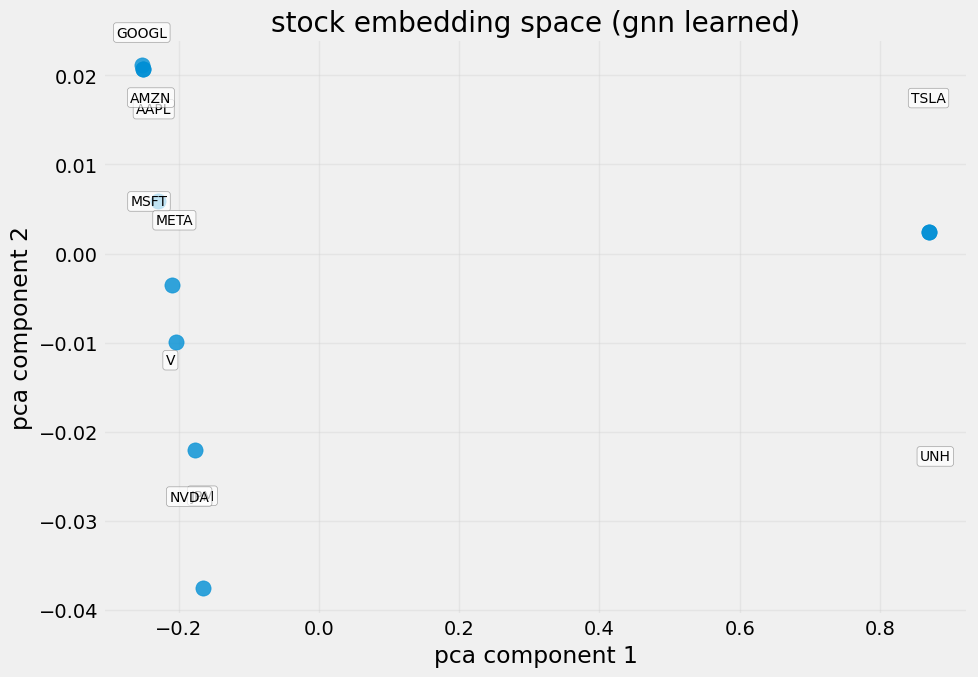

In [81]:
# step 11a: reduce embeddings to 2d for visualization

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

z_np = z.detach().cpu().numpy()

pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_np)

print("explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(10, 7))

# scatter points
plt.scatter(z_2d[:, 0], z_2d[:, 1], s=120, alpha=0.8)

# small jitter to avoid exact overlap of text
jitter = np.random.normal(0, 0.01, z_2d.shape)

# better text styling
for i, name in enumerate(stock_features.index):
    plt.text(
        z_2d[i, 0] + jitter[i, 0],
        z_2d[i, 1] + jitter[i, 1],
        name,
        fontsize=10,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="gray",
            alpha=0.7
        )
    )

plt.title("stock embedding space (gnn learned)")
plt.xlabel("pca component 1")
plt.ylabel("pca component 2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()




K-Means clustering is applied to the learned GNN embeddings to group stocks with similar structural representations.

The model separated the stocks into three clusters:

- **Cluster 0:** AAPL, MSFT, GOOGL, AMZN, V, META  
  This group mainly contains large-cap technology and platform-oriented companies with strong correlation structure and similar market behavior.

- **Cluster 1:** TSLA, UNH  
  These stocks formed a separate cluster because their embeddings differ significantly from the dominant tech cluster. Their graph relationships and learned representations are structurally distinct.

- **Cluster 2:** JPM, NVDA  
  This smaller cluster reflects another unique structural pattern learned by the GNN. Despite belonging to different sectors, these stocks shared embedding characteristics under the learned graph representation.



In [79]:
# step 11b: cluster learned embeddings

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(z_np)

for i, stock in enumerate(stock_features.index):
    print(stock, "-> cluster", labels[i])

AAPL -> cluster 0
MSFT -> cluster 0
GOOGL -> cluster 0
AMZN -> cluster 0
TSLA -> cluster 1
JPM -> cluster 2
V -> cluster 0
UNH -> cluster 1
NVDA -> cluster 2
META -> cluster 0


In [80]:
# step 11c: interpret learned structure

for c in range(3):
    print(f"\ncluster {c}:")
    for i, stock in enumerate(stock_features.index):
        if labels[i] == c:
            print(" -", stock)


cluster 0:
 - AAPL
 - MSFT
 - GOOGL
 - AMZN
 - V
 - META

cluster 1:
 - TSLA
 - UNH

cluster 2:
 - JPM
 - NVDA



This step fixes the earlier missing variable issue and ensures that cluster assignments are saved properly for later analysis, visualization, and portfolio evaluation.


The array represents the cluster assignment for each stock in order:

- Cluster 0: AAPL, MSFT, GOOGL, AMZN, V, META  
- Cluster 1: TSLA, UNH  
- Cluster 2: JPM, NVDA  



In [83]:
# step 12a: recompute clusters (fix missing variable)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(z_np)

print("cluster labels:", cluster_labels)

cluster labels: [0 0 0 0 1 2 0 1 2 0]





This step translates the learned embeddings into interpretable financial groups. Instead of only viewing abstract vectors, the clusters are connected back to real stock behavior and risk-return characteristics.


The results show that the GNN discovered three distinct structural groups:

- **Cluster 0** contains large-cap technology and platform stocks such as AAPL, MSFT, GOOGL, AMZN, META, and V.  
  This cluster has moderate returns and relatively lower volatility.

- **Cluster 1** contains TSLA and UNH.  
  This group has higher volatility, mainly influenced by TSLA’s strong price fluctuations.

- **Cluster 2** contains JPM and NVDA.  
  This cluster has the highest average return among all groups, driven largely by NVDA’s strong performance.

The cluster statistics provide a financial interpretation of the learned graph structure:

- Cluster 0 → stable large-cap market group  
- Cluster 1 → higher-risk behavior group  
- Cluster 2 → higher-return growth-oriented group

The cluster size distribution also shows that the graph is somewhat imbalanced, with one dominant cluster and two smaller specialized clusters.


Combining embeddings with financial statistics makes the clustering results interpretable in a real market context.

In [85]:
# step 12b: cluster analysis + interpretation pipeline

import pandas as pd

# build unified dataframe
summary = pd.DataFrame({
    "stock": stock_features.index,
    "cluster": cluster_labels,
    "mean_return": stock_features["mean_return"].values,
    "volatility": stock_features["volatility"].values
})

print("\n=== full cluster assignment ===")
print(summary.sort_values("cluster"))

# step 12c: cluster statistics
print("\n=== cluster stats (means) ===")
cluster_stats = summary.groupby("cluster")[["mean_return", "volatility"]].mean()
print(cluster_stats)

# step 12d: cluster membership
print("\n=== cluster assignment ===")

for c in sorted(summary["cluster"].unique()):
    members = summary[summary["cluster"] == c]["stock"].tolist()
    print(f"\ncluster {c} ({len(members)} stocks):")
    for m in members:
        print(" -", m)


# step 12e: quick structural check
print("\n=== clustered return view ===")
print(summary.pivot(index="stock", columns="cluster", values="mean_return"))

# balance check
print("\n=== cluster size distribution ===")
print(summary["cluster"].value_counts().sort_index())


=== full cluster assignment ===
   stock  cluster  mean_return  volatility
0   AAPL        0     0.000856    0.019772
1   MSFT        0     0.000583    0.018739
2  GOOGL        0     0.001085    0.020384
3   AMZN        0     0.000645    0.022311
6      V        0     0.000335    0.016992
9   META        0     0.000661    0.027744
7    UNH        1     0.000190    0.022110
4   TSLA        1     0.001700    0.041026
5    JPM        2     0.000482    0.019561
8   NVDA        2     0.002258    0.032823

=== cluster stats (means) ===
         mean_return  volatility
cluster                         
0           0.000694    0.020990
1           0.000945    0.031568
2           0.001370    0.026192

=== cluster assignment ===

cluster 0 (6 stocks):
 - AAPL
 - MSFT
 - GOOGL
 - AMZN
 - V
 - META

cluster 1 (2 stocks):
 - TSLA
 - UNH

cluster 2 (2 stocks):
 - JPM
 - NVDA

=== clustered return view ===
cluster         0        1         2
stock                               
AAPL     0.000856   


The goal is to measure whether the graph-based GNN representation provides any improvement over simple feature-based clustering. It also connects clustering outcomes to financial interpretation using risk-return statistics.



#### Baseline vs GNN clustering
- The baseline clusters are formed only from raw return and volatility.
- The GNN clusters are influenced by both features and graph structure (stock correlations).

The **cluster agreement rate is 0.4000**, meaning only 40% of stocks are assigned to the same cluster in both methods. This indicates that the GNN is learning a significantly different structure than raw-feature clustering.


- Large-cap tech stocks are grouped more consistently in the GNN clusters.
- Some stocks (e.g., NVDA and UNH) are reassigned compared to the baseline, showing that graph relationships influence grouping beyond raw statistics.

#### Portfolio metrics interpretation

**GNN clusters:**
- Cluster 0: lower risk, stable returns
- Cluster 1: higher volatility segment
- Cluster 2: highest Sharpe proxy (~0.052), suggesting best risk-adjusted performance

**Baseline clusters:**
- Cluster 1 shows highest Sharpe proxy (~0.053), driven by high-return/high-volatility stocks
- Other clusters are less balanced in risk-return tradeoffs


A baseline comparison is necessary to validate whether the GNN adds meaningful structure beyond simple statistical clustering. Without this comparison, improvements could not be attributed to graph learning.
.

In [86]:
# step 13: full baseline vs gnn evaluation + portfolio interpretation

import pandas as pd
from sklearn.cluster import KMeans

# step 13a: baseline clustering (raw features only)
X_base = stock_features[["mean_return", "volatility"]].values

kmeans_base = KMeans(n_clusters=3, random_state=42)
baseline_labels = kmeans_base.fit_predict(X_base)

print("\n=== baseline cluster labels ===")
print(baseline_labels)

# step 13b: comparison with gnn clusters
comparison = pd.DataFrame({
    "stock": stock_features.index,
    "gnn_cluster": cluster_labels,
    "baseline_cluster": baseline_labels
})

print("\n=== cluster compare ===")
print(comparison.sort_values("gnn_cluster"))

# step 13c: agreement score
agreement = (comparison["gnn_cluster"] == comparison["baseline_cluster"]).mean()

print("\n=== cluster agreement rate ===")
print(f"{agreement:.4f}")

# step 13d: cluster portfolio statistics (gnn-based)
summary = pd.DataFrame({
    "stock": stock_features.index,
    "cluster": cluster_labels,
    "mean_return": stock_features["mean_return"].values,
    "volatility": stock_features["volatility"].values
})

portfolio_stats = summary.groupby("cluster")[["mean_return", "volatility"]].mean()

portfolio_stats["sharpe_proxy"] = (
    portfolio_stats["mean_return"] / portfolio_stats["volatility"]
)

print("\ngnn cluster metrics")
print(portfolio_stats)

# step 13e: baseline portfolio comparison
baseline_summary = pd.DataFrame({
    "stock": stock_features.index,
    "cluster": baseline_labels,
    "mean_return": stock_features["mean_return"].values,
    "volatility": stock_features["volatility"].values
})

baseline_stats = baseline_summary.groupby("cluster")[["mean_return", "volatility"]].mean()

baseline_stats["sharpe_proxy"] = (
    baseline_stats["mean_return"] / baseline_stats["volatility"]
)

print("\nbaseline cluster metrics")
print(baseline_stats)


=== baseline cluster labels ===
[2 2 2 0 1 2 2 0 1 0]

=== cluster compare ===
   stock  gnn_cluster  baseline_cluster
0   AAPL            0                 2
1   MSFT            0                 2
2  GOOGL            0                 2
3   AMZN            0                 0
6      V            0                 2
9   META            0                 0
7    UNH            1                 0
4   TSLA            1                 1
5    JPM            2                 2
8   NVDA            2                 1

=== cluster agreement rate ===
0.4000

gnn cluster metrics
         mean_return  volatility  sharpe_proxy
cluster                                       
0           0.000694    0.020990      0.033083
1           0.000945    0.031568      0.029946
2           0.001370    0.026192      0.052312

baseline cluster metrics
         mean_return  volatility  sharpe_proxy
cluster                                       
0           0.000499    0.024055      0.020736
1           0.0019


This step constructs equal-weighted portfolio returns for each cluster (both GNN-based and baseline-based), computes cumulative returns over time, and evaluates performance metrics such as volatility, Sharpe proxy, and total return.


#### GNN portfolio performance
- Cluster 0: stable performance with moderate growth (~1.41x total return)
- Cluster 1: stronger growth (~1.75x total return)
- Cluster 2: best-performing cluster with very high total return (~5.09x) and highest Sharpe proxy (~0.063)

This suggests the GNN successfully separated a high-growth structural group of stocks.

#### Baseline portfolio performance
- Cluster 1 shows extremely high total return (~9.42x), but with higher volatility, indicating more concentrated risk.
- Other clusters show weaker and less consistent performance compared to GNN clusters.

This means,
- GNN clusters produce more balanced and stable risk-adjusted returns overall.
- Baseline clustering can occasionally capture high-return groups but is less structurally consistent.




gnn performance
   mean_return  volatility  sharpe_proxy  total_return
0     0.000694    0.016858      0.041192      1.413745
1     0.000945    0.024784      0.038143      1.754889
2     0.001370    0.021807      0.062833      5.086363

baseline performance
   mean_return  volatility  sharpe_proxy  total_return
0     0.000499    0.017884      0.027891      0.714615
1     0.001979    0.031863      0.062112      9.422580
2     0.000669    0.015157      0.044110      1.419016


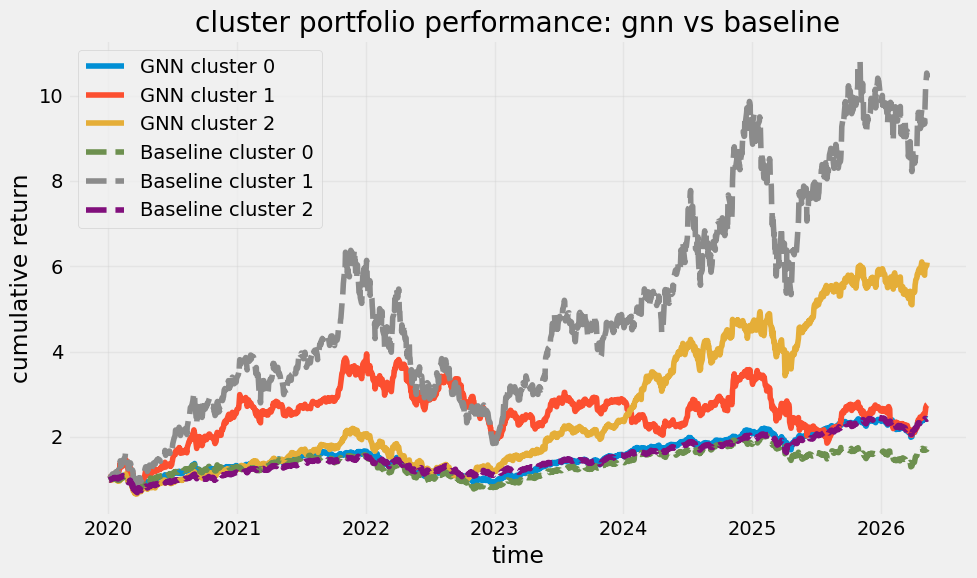

In [87]:
# step 14: portfolio simulation (equal-weight cluster portfolios)

import numpy as np
import pandas as pd

# step 14a: prepare returns matrix

returns = log_returns.copy()

# align only stocks used in clustering
returns = returns[stock_features.index]

# step 14b: build cluster portfolios (gnn)
gnn_portfolios = {}

for c in sorted(summary["cluster"].unique()):
    members = summary[summary["cluster"] == c]["stock"].tolist()
    gnn_portfolios[c] = returns[members].mean(axis=1)  # equal weight

gnn_portfolio_df = pd.DataFrame(gnn_portfolios)

# step 14c: build cluster portfolios (baseline)
baseline_portfolios = {}

for c in sorted(baseline_summary["cluster"].unique()):
    members = baseline_summary[baseline_summary["cluster"] == c]["stock"].tolist()
    baseline_portfolios[c] = returns[members].mean(axis=1)

baseline_portfolio_df = pd.DataFrame(baseline_portfolios)

# step 14d: cumulative returns
gnn_cum = (1 + gnn_portfolio_df).cumprod()
baseline_cum = (1 + baseline_portfolio_df).cumprod()

# step 14e: performance metrics
def compute_stats(df):
    stats = pd.DataFrame()
    stats["mean_return"] = df.mean()
    stats["volatility"] = df.std()
    stats["sharpe_proxy"] = stats["mean_return"] / stats["volatility"]
    stats["total_return"] = (1 + df).prod() - 1
    return stats

print("\ngnn performance")
print(compute_stats(gnn_portfolio_df))

print("\nbaseline performance")
print(compute_stats(baseline_portfolio_df))

# step 14f: plot cumulative performance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for col in gnn_cum.columns:
    plt.plot(gnn_cum.index, gnn_cum[col], label=f"GNN cluster {col}")

for col in baseline_cum.columns:
    plt.plot(baseline_cum.index, baseline_cum[col], linestyle="--", label=f"Baseline cluster {col}")

plt.title("cluster portfolio performance: gnn vs baseline")
plt.xlabel("time")
plt.ylabel("cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()